# Voz del Cliente más allá del NPS
## ITESM - Proyecto Integrador 2026
### Equipo 14

**Alumnos:**
Mario Arturo Salinas Rodríguez - **A01796938**
| Esteban Guerrero Rivero - **A01795053**
| Néstor Javier Hernández Bautista - **A00394821**

**Profesor:** Dr. Carlos Alberto Villaseñor Padilla
**Patrocinador:** Pablo Agustín Velázquez, Banamex

### Análisis exploratorio de reseñas
El objetivo es describir la calidad de los datos, los patrones del texto y las diferencias
entre plataformas y calificaciones. Se conserva la estructura del notebook de referencia
y se agrega una sección que responde las diez preguntas de la actividad.

La publicación de origen es **b7a61a8b-27d8-46a7-b2ce-67d97268b741 (80,079 filas)**;
todo el análisis de texto de esta entrega se limita a la muestra.

## 1. Identificación y carga del conjunto de datos

Carga inicial del conjunto de datos para conocer su estructura general, esto con el objetivo de confirmar que la información fue importada correctamente y conocer las variables disponibles antes de comenzar con el análisis exploratorio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import unicodedata
from collections import Counter
from IPython.display import display, Markdown


In [2]:
from voc import collector as co

snapshot = co.get_dataset(version="latest")
df = snapshot.data

df.head()

,record_id,platform,app_id,country,text,title,model_text,text_hash,rating,record_date,date_basis,date_precision,date_timezone,language,language_basis,relevance,preferred_provider,identity_basis
0,appbot:498483038:3606491475,app_store,498483038,MX,Quiero ver mis movimientos y no me deja regres...,Errores en la app para ver movimientos,Quiero ver mis movimientos y no me deja regres...,d5a838f3cbc3912516bdf5832d02e7cc51e09c8e7f2d0f...,2,2025-09-01,provider_published_at,day,unknown,es,provider language field,app_target_match,appbot,provider_identity
1,appbot:498483038:3606491476,app_store,498483038,MX,"No me permite ver mis movimientos, está descon...",Mala aplicación,"No me permite ver mis movimientos, está descon...",7c2f6c168877f40be7f0a66e5666a3468e8c97710b53af...,2,2025-09-01,provider_published_at,day,unknown,es,provider language field,app_target_match,appbot,provider_identity
2,appbot:498483038:3606491477,app_store,498483038,MX,Todo bien,Recomendable,Todo bien,a53bc6df3058125dade7dd8f07ed6f1a5fd378634b10c2...,5,2025-09-01,provider_published_at,day,unknown,es,provider language field,app_target_match,appbot,provider_identity
3,appbot:498483038:3606711369,app_store,498483038,MX,La app esta muy bien solo tiene un detalle neg...,Bloqueo temporal de tarjeta de débito,La app esta muy bien solo tiene un detalle neg...,188f16374700a7dcaf98bb0466263fa5c51c689c6089d6...,4,2025-09-01,provider_published_at,day,unknown,es,provider language field,app_target_match,appbot,provider_identity
4,appbot:498483038:3606711370,app_store,498483038,MX,Con sus actualizaciones ha quedado una aplicac...,Calificación,Con sus actualizaciones ha quedado una aplicac...,63c0ca491e55ae2f1acb760b03f7f67bece3436fc176b0...,5,2025-09-01,provider_published_at,day,unknown,es,provider language field,app_target_match,appbot,provider_identity


## 2. Calidad y estructura de los datos

Evaluación de la calidad general del conjunto de datos, mediante la revisión dle tipo de variables que lo intetgran, valores faltantes, datos duplicados y otras características básicas.


In [3]:
dataset_identity = pd.DataFrame(
    [{"Campo": k, "Valor": snapshot.info.get(k, "no disponible")}
     for k in ["release_id", "artifact_id", "raw_revision_id", "row_count"]]
)

quality = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores faltantes": df.isna().sum().values,
    "Faltantes (%)": (df.isna().mean() * 100).round(2).values,
    "Valores distintos": df.nunique(dropna=True).values
})

quality_checks = pd.DataFrame({
    "Control": [
        "Filas", "Columnas", "Identificadores faltantes",
        "Identificadores repetidos", "Textos originales vacíos",
        "Textos preparados vacíos", "Textos preparados repetidos",
        "Diferencias entre texto original y preparado"
    ],
    "Cantidad": [
        len(df), df.shape[1],
        df["record_id"].isna().sum(),
        df["record_id"].dropna().duplicated().sum(),
        df["text"].fillna("").str.strip().eq("").sum(),
        df["model_text"].fillna("").str.strip().eq("").sum(),
        df.loc[df["model_text"].fillna("").str.strip().ne(""), "model_text"].duplicated().sum(),
        df["text"].fillna("").ne(df["model_text"].fillna("")).sum()
    ]
})

display(dataset_identity)
display(quality_checks)
display(quality)


,Campo,Valor
0,release_id,b7a61a8b-27d8-46a7-b2ce-67d97268b741
1,artifact_id,cc832e1a-bf72-4af6-821e-4291f65b016b
2,raw_revision_id,a83338e6-b608-4a1c-b270-9356d922e840
3,row_count,80079


,Control,Cantidad
0,Filas,80079
1,Columnas,18
2,Identificadores faltantes,0
3,Identificadores repetidos,0
4,Textos originales vacíos,0
5,Textos preparados vacíos,0
6,Textos preparados repetidos,23314
7,Diferencias entre texto original y preparado,0


,Variable,Tipo de dato,Valores faltantes,Faltantes (%),Valores distintos
0,record_id,string,0,0.00,80079
1,platform,string,0,0.00,4
2,app_id,string,7881,9.84,2
3,country,string,7881,9.84,1
4,text,string,0,0.00,56765
5,title,string,74878,93.51,3143
6,model_text,string,0,0.00,56765
7,text_hash,string,0,0.00,56765
8,rating,Int64,7881,9.84,5
9,record_date,string,0,0.00,75172


In [4]:
categorical_columns = [
    "platform",
    "language",
    "date_basis",
    "date_precision",
    "date_timezone",
    "relevance",
    "preferred_provider",
    "identity_basis",
    "country",
    "app_id"
]

cardinality = pd.DataFrame({
    "Variable": categorical_columns,
    "Cardinalidad": [
        df[col].nunique(dropna=True)
        for col in categorical_columns
    ]
})

display(cardinality)

,Variable,Cardinalidad
0,platform,4
1,language,38
2,date_basis,4
3,date_precision,2
4,date_timezone,2
5,relevance,5
6,preferred_provider,5
7,identity_basis,3
8,country,1
9,app_id,2


## 3. Preparación del conjunto para el análisis exploratorio

Preparación de las variables que seran utilizadas durante el EDA, se convierten fechas, valoraciones y textos a formatos adecuados, los valores nulos se reemplazan por una cadena vacía.



In [5]:
eda = df.copy()

analysis_text = eda["text"].fillna("").astype(str)
parsed_dates = pd.to_datetime(eda["record_date"], errors="coerce", format="mixed", utc=True)
ratings = pd.to_numeric(eda["rating"], errors="coerce")

print(f"Selección: {len(eda):,} reseñas")
print(f"Sin idioma indicado: {eda['language'].isna().sum():,}")
print(f"Sin estrellas: {ratings.isna().sum():,}")
print(f"Sin fecha válida: {parsed_dates.isna().sum():,}")


Selección: 80,079 reseñas
Sin idioma indicado: 68,382
Sin estrellas: 7,881
Sin fecha válida: 0


## 4. Distribución general de los datos

Análisis de la distribución  de las reseñas segun plataforma, valoración, fecha y longitud del texto permite obtener una primera perspectiva sobre la composición del conjunto de datos y detectar posibles concentraciones, desbalances o valores atípicos.

In [6]:
platform_summary = (
    eda.groupby("platform", dropna=False)
       .agg(
           Reseñas=("record_id", "size"),
           Reseñas_con_estrellas=("rating", "count"),
           Promedio_estrellas=("rating", "mean")
       )
       .round(2)
       .reset_index()
)

language_summary = (
    eda["language"].fillna("desconocido")
       .value_counts()
       .rename_axis("Idioma")
       .reset_index(name="Reseñas")
)

date_provenance = (
    eda.groupby(["date_basis"], dropna=False)
       .size()
       .reset_index(name="Reseñas")
)

display(platform_summary)
display(language_summary)
display(date_provenance)


,platform,Reseñas,Reseñas_con_estrellas,Promedio_estrellas
0,app_store,5201,5201,2.6
1,google_play,66997,66997,4.02
2,x,6553,0,<NA>
3,youtube,1328,0,<NA>


,Idioma,Reseñas
0,desconocido,68382
1,es,11401
2,en,172
3,pt,37
4,gl,17
5,sk,8
6,id,6
7,war,6
8,ca,5
9,la,4


,date_basis,Reseñas
0,earliest_observed_edit_family_creation,6553
1,provider_published_at,5151
2,published_at,1328
3,source_updated_at,67047


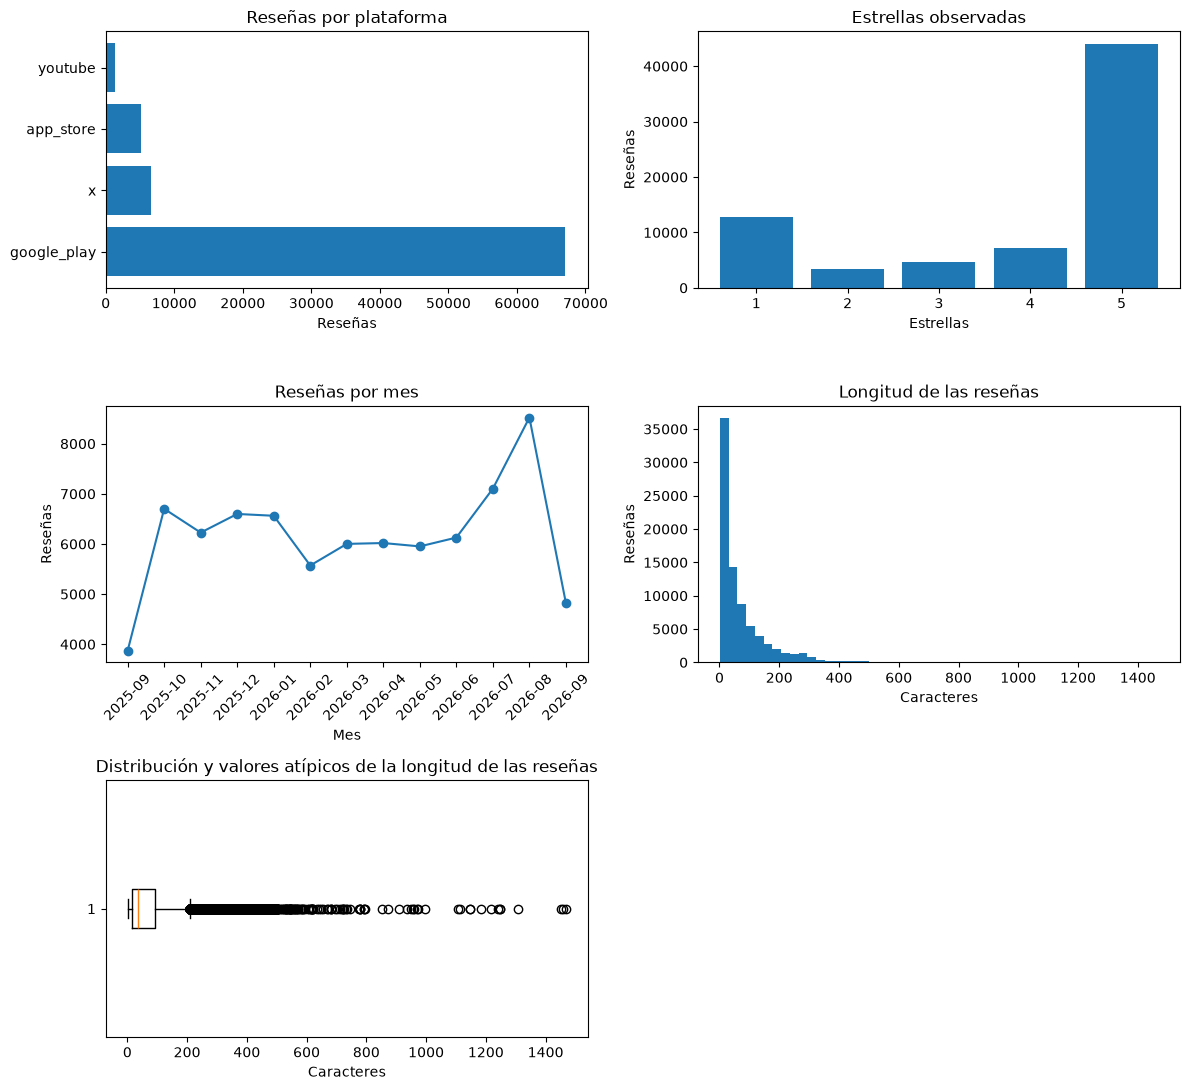

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 11))

platform_counts = eda["platform"].value_counts()
axes[0, 0].barh(platform_counts.index, platform_counts.values)
axes[0, 0].set(title="Reseñas por plataforma", xlabel="Reseñas")

rating_counts = ratings.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
axes[0, 1].bar(rating_counts.index, rating_counts.values)
axes[0, 1].set(
    title="Estrellas observadas",
    xlabel="Estrellas",
    ylabel="Reseñas",
    xticks=[1, 2, 3, 4, 5]
)

months = parsed_dates.dropna().dt.strftime("%Y-%m").value_counts().sort_index()
if not months.empty:
    axes[1, 0].plot(months.index, months.values, marker="o")
    axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].set(
    title="Reseñas por mes",
    xlabel="Mes",
    ylabel="Reseñas"
)

text_lengths = analysis_text.str.len()

axes[1, 1].hist(text_lengths, bins=50)
axes[1, 1].set(
    title="Longitud de las reseñas",
    xlabel="Caracteres",
    ylabel="Reseñas"
)

axes[2, 0].boxplot(text_lengths, orientation="horizontal")
axes[2, 0].set(
    title="Distribución y valores atípicos de la longitud de las reseñas",
    xlabel="Caracteres"
)

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()


In [8]:
Q1 = text_lengths.quantile(0.25)
Q3 = text_lengths.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = text_lengths[
    (text_lengths < limite_inferior) |
    (text_lengths > limite_superior)
]

print(f"Q1: {Q1:.0f}")
print(f"Q3: {Q3:.0f}")
print(f"IQR: {IQR:.0f}")
print(f"Límite superior: {limite_superior:.0f} caracteres")
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers) / len(text_lengths) * 100:.2f}%")

Q1: 14
Q3: 92
IQR: 78
Límite superior: 209 caracteres
Cantidad de outliers: 6096
Porcentaje de outliers: 7.61%


,count,mean,median
Estrellas,,,
1,12774,114.3,81.0
2,3413,118.1,85.0
3,4684,96.9,70.0
4,7236,66.7,43.0
5,44091,34.9,20.0


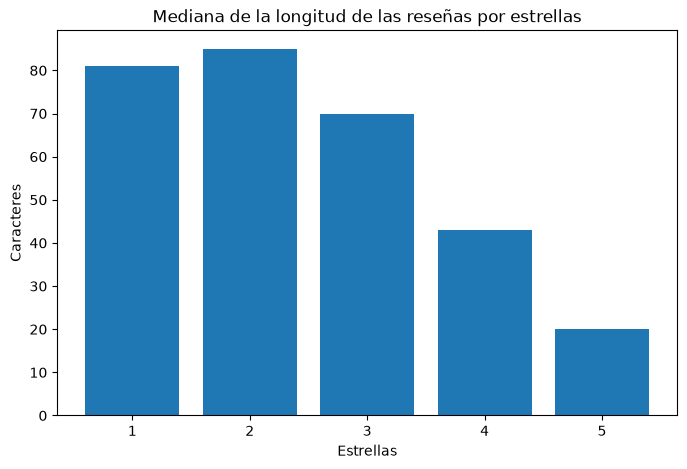

In [9]:
length_rating = pd.DataFrame({
    "Estrellas": ratings,
    "Longitud": analysis_text.str.len()
}).dropna()

length_summary_rating = (
    length_rating
    .groupby("Estrellas")["Longitud"]
    .agg(["count", "mean", "median"])
    .round(1)
)

display(length_summary_rating)

median_length = (
    length_rating
    .groupby("Estrellas")["Longitud"]
    .median()
)

plt.figure(figsize=(8, 5))

plt.bar(
    median_length.index,
    median_length.values
)

plt.title("Mediana de la longitud de las reseñas por estrellas")
plt.xlabel("Estrellas")
plt.ylabel("Caracteres")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [10]:
text_lengths = analysis_text.str.len()

print("Sesgo longitud:", round(text_lengths.skew(), 2))
print("Sesgo log1p:", round(np.log1p(text_lengths).skew(), 2))

platform_pct = eda["platform"].value_counts(normalize=True) * 100

display(platform_pct.round(2))

bias_summary = pd.DataFrame({
    "Plataforma": eda["platform"].value_counts().index,
    "Porcentaje": (
        eda["platform"].value_counts(normalize=True).values * 100
    ).round(2)
})

display(bias_summary)

print(f"Asimetría longitud: {text_lengths.skew():.2f}")
print(f"Mayor participación por plataforma: {platform_pct.max():.2f}%")

Sesgo longitud: 2.69
Sesgo log1p: 0.13


platform
google_play    83.66
x               8.18
app_store       6.49
youtube         1.66
Name: proportion, dtype: Float64

,Plataforma,Porcentaje
0,google_play,83.66
1,x,8.18
2,app_store,6.49
3,youtube,1.66


Asimetría longitud: 2.69
Mayor participación por plataforma: 83.66%


## 5. Patrones lingüísticos y de formato

Identificación de características presentes en el contenido textual, como negaciones, uso de mayúsculas, emojis, URLs, signos repetidos y otros patrones de escritura, el objetivo es conocer mejor la forma en que los usuarios expresan sus opiniones y determinar qué elementos podrían ser relevantes para el análisis de sentimiento.

In [11]:
pattern_rules = {
    "Signos repetidos": r"[!?¡¿]{2,}",
    "Mayúsculas": r"\b[A-ZÁÉÍÓÚÜÑ]{2,}\b",
    "Negaciones": r"(?i)\b(?:no|nunca|jamás|tampoco|sin|ni)\b",
    "Emojis": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    "URLs": r"https?://\S+|www\.\S+",
    "Cantidades con $": r"\$\s*\d[\d,]*(?:\.\d{1,2})?",
}

rows = []

for name, pattern in pattern_rules.items():
    hits = analysis_text.str.contains(pattern, regex=True, na=False)

    rows.append({
        "Patrón": name,
        "Reseñas": hits.sum(),
        "Porcentaje": round(hits.mean() * 100, 2)
    })

# Letras repetidas, por ejemplo "bueeeno", "maaal", "siii"
hits = analysis_text.str.extract(
    r"([^\W\d_])\1{2,}",
    expand=False
).notna()

rows.append({
    "Patrón": "Letras repetidas",
    "Reseñas": hits.sum(),
    "Porcentaje": round(hits.mean() * 100, 2)
})

pattern_summary = pd.DataFrame(rows)
pattern_summary = pattern_summary.sort_values("Porcentaje", ascending=False)

display(pattern_summary)


,Patrón,Reseñas,Porcentaje
2,Negaciones,23928,29.88
3,Emojis,4400,5.49
1,Mayúsculas,3505,4.38
0,Signos repetidos,1800,2.25
4,URLs,1055,1.32
6,Letras repetidas,358,0.45
5,Cantidades con $,208,0.26


## 6. Tokenización y limpieza básica del texto

Limpieza inicial de las reseñas y tokenización, esto procedimiento facilita los análisis posteriores de frecuencia y permite observar cómo se transforma el texto después de eliminar elementos que no aportan información relevante. 
Por el momento la limpieza se utiliza únicamente con fines exploratorios y no modifica las columnas originales del conjunto de datos.

In [12]:
def tokenize(text):
    text = unicodedata.normalize("NFC", str(text)).casefold()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return re.findall(r"[^\W\d_]+", text)

tokens = analysis_text.apply(tokenize)
cleaned_text = tokens.apply(" ".join)

preview = pd.DataFrame({
    "Plataforma": eda["platform"],
    "Texto original": analysis_text,
    "Texto limpio": cleaned_text,
    "Número de palabras": tokens.apply(len)
})

display(preview.sample(10, random_state=42))


,Plataforma,Texto original,Texto limpio,Número de palabras
74875,x,"@http_HectorLN ¡Hola, Héctor! Lamentamos que n...",http hectorln hola héctor lamentamos que no pu...,36
40064,google_play,Solo me pase con ustedes por el token físico p...,solo me pase con ustedes por el token físico p...,57
957,app_store,No aparecen los movimientos de queda cargando ...,no aparecen los movimientos de queda cargando ...,12
43425,google_play,fantástica,fantástica,1
66501,google_play,exelente,exelente,1
52312,google_play,Siempre disponible y super fácil de usar,siempre disponible y super fácil de usar,7
59951,google_play,excelente atención,excelente atención,2
74224,x,Nuestros cachorritos están en busca de padrino...,nuestros cachorritos están en busca de padrino...,40
20657,google_play,excelente,excelente,1
67739,google_play,Muy buena aplicación.,muy buena aplicación,3


## 7. Frecuencia de palabras y bigramas

En esta sección se estudian las palabras y combinaciones de palabras más frecuentes dentro de las reseñas, se eliminan las stopwords para reducir el peso de términos muy comunes y concentrar el análisis en palabras con mayor contenido semántico.

Las negaciones se conservan porque pueden modificar de forma importante el significado de una frase.

In [13]:
spanish_stopwords = set("""
a al algo algunas algunos ante antes como con contra cual cuando de del desde
donde durante e el ella ellas ellos en entre era eran eres es esa esas ese esos
esta estaba estaban estamos estan estar estas este esto estos fue fueron ha
haber habia han hasta hay la las le les lo los mas me mi mis muy nos nosotros
o os otra otras otro otros para pero por porque que quien se ser si sobre son
su sus te tiene tienen todo todos tu tus un una unas uno unos usted ustedes y
ya él más mí qué quién cómo cuándo dónde está están había también
""".split())

# Keep negations because they can change sentiment.
spanish_stopwords -= {"no", "nunca", "jamás", "tampoco", "sin", "ni"}

filtered_tokens = tokens.apply(
    lambda words: [word for word in words if word not in spanish_stopwords]
)

# Word frequency
word_counts = Counter(
    word
    for words in filtered_tokens
    for word in words
)

# Number of reviews where each word appears
document_counts = Counter(
    word
    for words in filtered_tokens
    for word in set(words)
)

# Most common bigrams
bigrams = Counter(
    f"{words[i]} {words[i + 1]}"
    for words in filtered_tokens
    for i in range(len(words) - 1)
)

vocabulary_summary = pd.DataFrame({
    "Indicador": [
        "Palabras antes de eliminar stopwords",
        "Palabras después de eliminar stopwords",
        "Vocabulario",
        "Reseñas vacías después de tokenizar",
        "Reseñas vacías después de stopwords"
    ],
    "Cantidad": [
        tokens.apply(len).sum(),
        filtered_tokens.apply(len).sum(),
        len(word_counts),
        tokens.apply(len).eq(0).sum(),
        filtered_tokens.apply(len).eq(0).sum()
    ]
})

top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=["Palabra", "Apariciones"]
)

top_words["Reseñas"] = top_words["Palabra"].map(document_counts)

top_words["Reseñas (%)"] = (
    top_words["Reseñas"] / len(eda) * 100
).round(2)

top_bigrams = pd.DataFrame(
    bigrams.most_common(10),
    columns=["Par de palabras", "Apariciones"]
)

display(vocabulary_summary)
display(top_words)
display(top_bigrams)

,Indicador,Cantidad
0,Palabras antes de eliminar stopwords,976629
1,Palabras después de eliminar stopwords,570901
2,Vocabulario,22027
3,Reseñas vacías después de tokenizar,323
4,Reseñas vacías después de stopwords,398


,Palabra,Apariciones,Reseñas,Reseñas (%)
0,no,30458,20869,26.06
1,app,18278,16482,20.58
2,aplicación,13084,12205,15.24
3,excelente,12263,12130,15.15
4,buena,11664,11541,14.41
5,banamex,8765,7780,9.72
6,bien,6528,6341,7.92
7,servicio,5088,4961,6.20
8,fácil,4785,4731,5.91
9,banco,4395,3956,4.94


,Par de palabras,Apariciones
0,no puedo,2663
1,no deja,2650
2,fácil usar,1929
3,buena aplicación,1808
4,app no,1750
5,buena app,1737
6,excelente servicio,1572
7,excelente aplicación,1467
8,no abre,1356
9,excelente app,1125


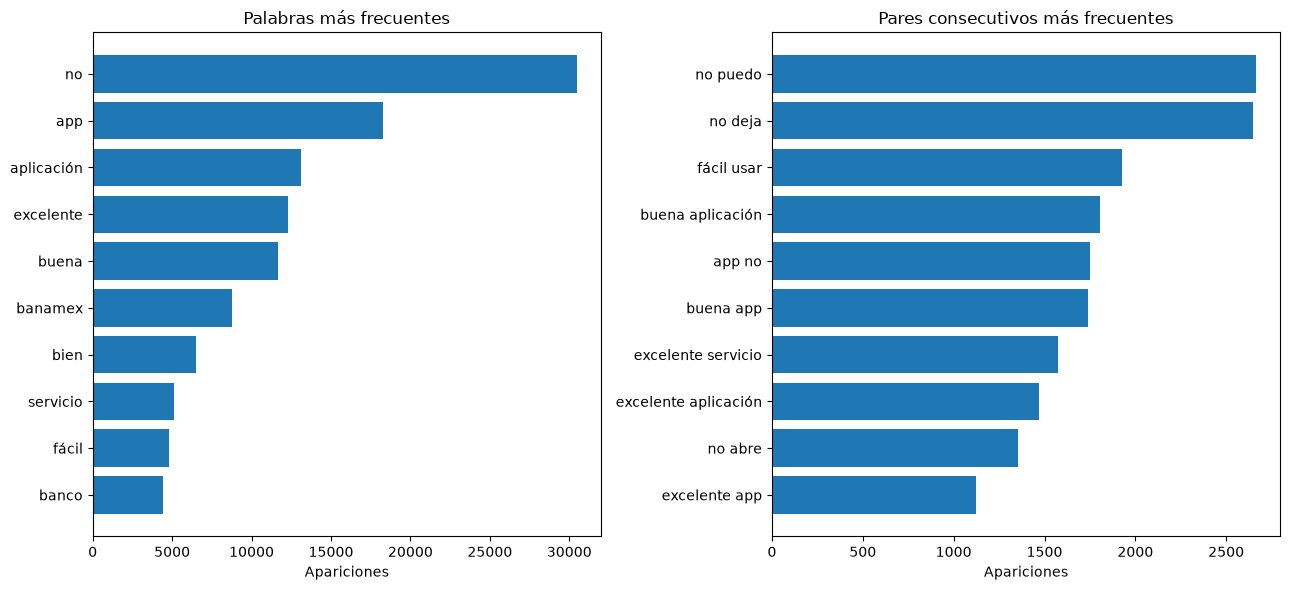

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

words_plot = top_words.head(15).iloc[::-1]
axes[0].barh(words_plot["Palabra"], words_plot["Apariciones"])
axes[0].set(title="Palabras más frecuentes", xlabel="Apariciones")

bigrams_plot = top_bigrams.head(15).iloc[::-1]
axes[1].barh(bigrams_plot["Par de palabras"], bigrams_plot["Apariciones"])
axes[1].set(title="Pares consecutivos más frecuentes", xlabel="Apariciones")

plt.tight_layout()
plt.show()


## 8. Comparación de palabras según la valoración

El objetivo es identificar términos que aparecen con mayor frecuencia en opiniones de 1–2 estrellas o de 4–5 estrellas y explorar su posible relación con la valoración otorgada por los usuarios.

Las calificaciones se utilizan como una aproximación descriptiva y no como etiquetas de sentimientO.

In [15]:
low_mask = ratings.isin([1, 2])
high_mask = ratings.isin([4, 5])

low_n = low_mask.sum()
high_n = high_mask.sum()

low_counts = Counter(word for tokens in filtered_tokens[low_mask] for word in set(tokens))
high_counts = Counter(word for tokens in filtered_tokens[high_mask] for word in set(tokens))

rows = []

for word in set(low_counts) | set(high_counts):
    if low_counts[word] + high_counts[word] < 10:
        continue

    low_pct = 100 * low_counts[word] / low_n if low_n else 0
    high_pct = 100 * high_counts[word] / high_n if high_n else 0

    rows.append({
        "Palabra": word,
        "Reseñas 1-2": low_counts[word],
        "Reseñas 4-5": high_counts[word],
        "1-2 estrellas (%)": low_pct,
        "4-5 estrellas (%)": high_pct,
        "Diferencia": low_pct - high_pct
    })

rating_word_comparison = pd.DataFrame(rows).round(2)

print(f"Grupo 1-2 estrellas: {low_n:,} reseñas")
print(f"Grupo 4-5 estrellas: {high_n:,} reseñas")

display(Markdown("**Palabras más frecuentes en reseñas de 1-2 estrellas**"))
display(rating_word_comparison.sort_values("Diferencia", ascending=False).head(10))

display(Markdown("**Palabras más frecuentes en reseñas de 4-5 estrellas**"))
display(rating_word_comparison.sort_values("Diferencia").head(10))

Grupo 1-2 estrellas: 16,187 reseñas
Grupo 4-5 estrellas: 51,327 reseñas


**Palabras más frecuentes en reseñas de 1-2 estrellas**

,Palabra,Reseñas 1-2,Reseñas 4-5,1-2 estrellas (%),4-5 estrellas (%),Diferencia
1443,no,9492,4398,58.64,8.57,50.07
640,app,4269,6225,26.37,12.13,14.24
1378,aplicación,3611,6339,22.31,12.35,9.96
902,deja,1722,403,10.64,0.79,9.85
1739,entrar,1423,481,8.79,0.94,7.85
2498,banco,1734,1472,10.71,2.87,7.84
1318,abrir,1351,558,8.35,1.09,7.26
1178,mucho,1635,1564,10.10,3.05,7.05
1026,falla,1296,491,8.01,0.96,7.05
1434,hacer,1563,1338,9.66,2.61,7.05


**Palabras más frecuentes en reseñas de 4-5 estrellas**

,Palabra,Reseñas 1-2,Reseñas 4-5,1-2 estrellas (%),4-5 estrellas (%),Diferencia
1271,excelente,68,11837,0.42,23.06,-22.64
1794,buena,238,10946,1.47,21.33,-19.86
781,fácil,117,4505,0.72,8.78,-8.05
1605,bien,542,5337,3.35,10.40,-7.05
1433,gracias,113,2476,0.70,4.82,-4.13
913,exelente,10,1840,0.06,3.58,-3.52
525,rápida,34,1707,0.21,3.33,-3.12
324,usar,430,2858,2.66,5.57,-2.91
1234,práctica,46,1495,0.28,2.91,-2.63
1100,buen,80,1546,0.49,3.01,-2.52


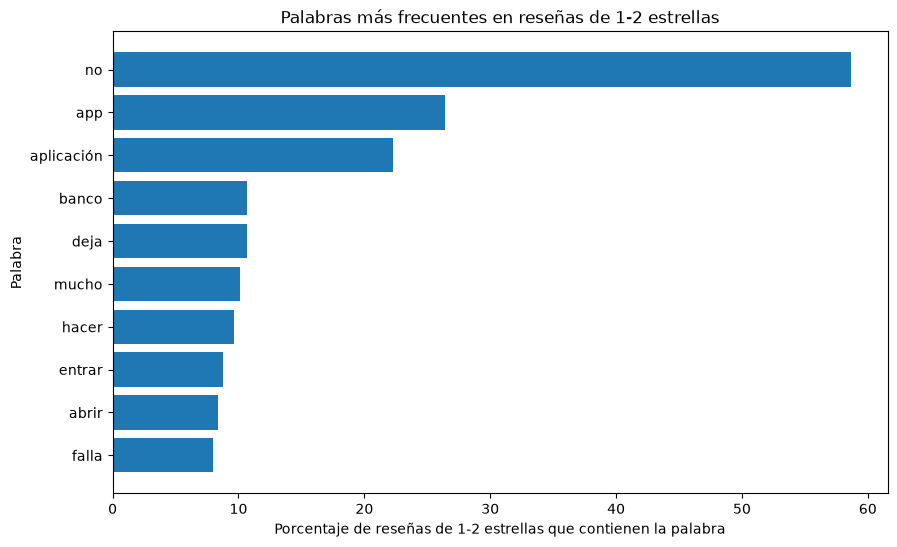

In [16]:
top_negative = (
    rating_word_comparison
    .sort_values("Diferencia", ascending=False)
    .head(10)
    .sort_values("1-2 estrellas (%)")
)

plt.figure(figsize=(10, 6))
plt.barh(top_negative["Palabra"], top_negative["1-2 estrellas (%)"])
plt.xlabel("Porcentaje de reseñas de 1-2 estrellas que contienen la palabra")
plt.ylabel("Palabra")
plt.title("Palabras más frecuentes en reseñas de 1-2 estrellas")
plt.show()

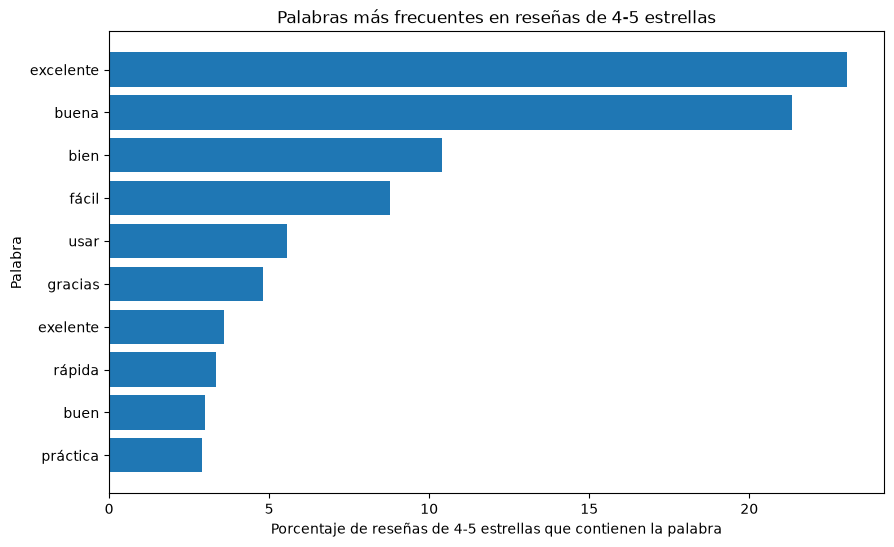

In [17]:
top_positive = (
    rating_word_comparison
    .sort_values("Diferencia", ascending=True)
    .head(10)
    .sort_values("4-5 estrellas (%)")
)

plt.figure(figsize=(10, 6))
plt.barh(top_positive["Palabra"], top_positive["4-5 estrellas (%)"])
plt.xlabel("Porcentaje de reseñas de 4-5 estrellas que contienen la palabra")
plt.ylabel("Palabra")
plt.title("Palabras más frecuentes en reseñas de 4-5 estrellas")
plt.show()

## 9. Análisis adicional

En esta sección se profundiza en algunas relaciones relevantes entre las variables del conjunto de datos. Se analizan la longitud de las reseñas, la distribución de estrellas por plataforma, la presencia de textos duplicados y la cobertura temporal de las diferentes fuentes.

### 9.1 Longitud de las reseñas según la valoración

Este análisis compara la extensión de las reseñas entre distintos grupos de estrellas. Su objetivo es identificar si los usuarios tienden a escribir comentarios más largos o más breves dependiendo de la valoración otorgada.

,count,median,mean,max
Grupo,,,,
1-2 estrellas,16187,82.0,115.1,1468
3 estrellas,4684,70.0,96.9,872
4-5 estrellas,51327,20.0,39.4,735


<Figure size 900x500 with 0 Axes>

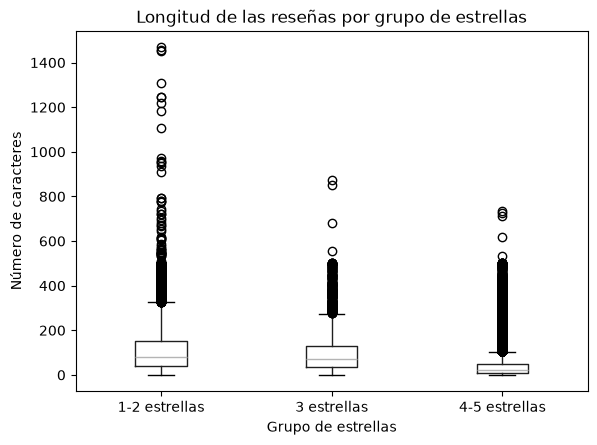

In [18]:
length_by_rating = pd.DataFrame({
    "Estrellas": ratings,
    "Longitud": analysis_text.str.len()
}).dropna()

length_by_rating["Grupo"] = pd.cut(
    length_by_rating["Estrellas"],
    bins=[0, 2, 3, 5],
    labels=["1-2 estrellas", "3 estrellas", "4-5 estrellas"]
)

display(
    length_by_rating
    .groupby("Grupo", observed=True)["Longitud"]
    .agg(["count", "median", "mean", "max"])
    .round(1)
)

plt.figure(figsize=(9, 5))

length_by_rating.boxplot(
    column="Longitud",
    by="Grupo",
    grid=False
)

plt.title("Longitud de las reseñas por grupo de estrellas")
plt.suptitle("")
plt.xlabel("Grupo de estrellas")
plt.ylabel("Número de caracteres")

plt.show()

### 9.2 Distribución de estrellas por plataforma

Comparación de la distribución porcentual de las calificaciones entre las diferentes plataformas, esto permite detectar si alguna fuente concentra una mayor proporción de reseñas positivas, negativas o neutrales.

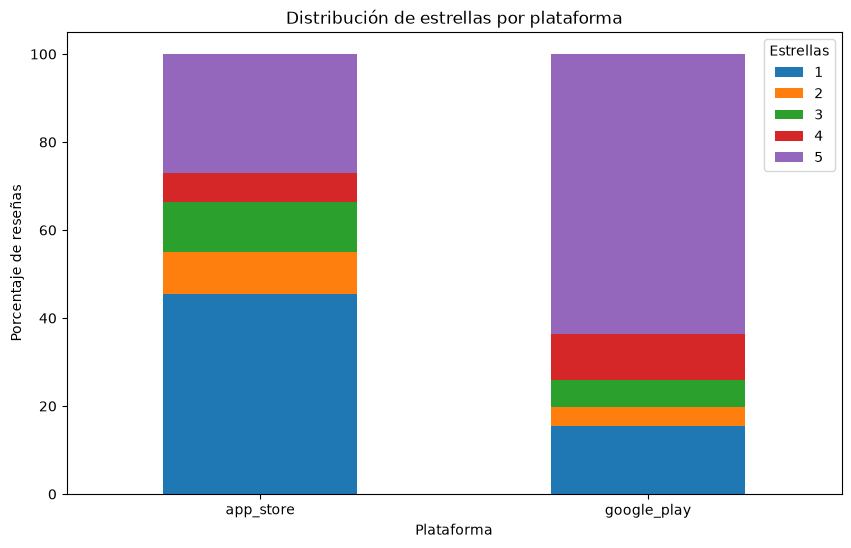

In [19]:
rating_platform = pd.crosstab(
    eda["platform"],
    ratings,
    normalize="index"
) * 100

rating_platform = rating_platform.reindex(
    columns=[1, 2, 3, 4, 5],
    fill_value=0
)

rating_platform.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de estrellas por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Porcentaje de reseñas")
plt.legend(title="Estrellas")
plt.xticks(rotation=0)

plt.show()

### 9.3 Textos duplicados por plataforma

En esta sección se analiza la presencia de comentarios repetidos dentro de cada plataforma, esto es escencial para verficar la información obtenida del web scrapping.

,Plataforma,Textos duplicados,Porcentaje
0,google_play,24894,37.16
1,app_store,377,7.25
2,x,34,0.52
3,youtube,27,2.03


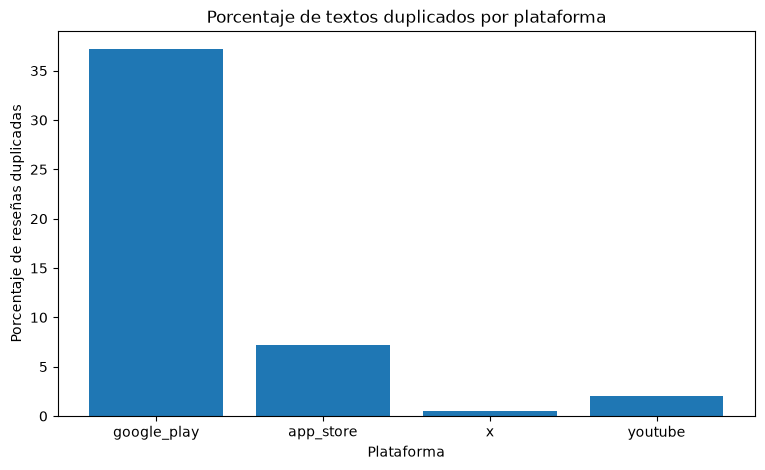

In [20]:
duplicate_mask = (
    eda["model_text"].fillna("").str.strip().ne("")
    & eda["model_text"].fillna("").duplicated(keep=False)
)

duplicates_by_platform = (
    eda.loc[duplicate_mask, "platform"]
    .value_counts()
    .rename_axis("Plataforma")
    .reset_index(name="Textos duplicados")
)

total_by_platform = eda["platform"].value_counts()

duplicates_by_platform["Porcentaje"] = (
    duplicates_by_platform["Textos duplicados"]
    / duplicates_by_platform["Plataforma"].map(total_by_platform)
    * 100
).round(2)

display(duplicates_by_platform)

plt.figure(figsize=(9, 5))

plt.bar(
    duplicates_by_platform["Plataforma"],
    duplicates_by_platform["Porcentaje"]
)

plt.title("Porcentaje de textos duplicados por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Porcentaje de reseñas duplicadas")

plt.show()

### 9.4 Cobertura temporal por plataforma

El objetivo es verificar si todas las fuentes representan intervalos temporales similares y evitar interpretaciones incorrectas de las tendencias observadas.

In [21]:
temporal_coverage = (
    eda.assign(
        Fecha=pd.to_datetime(
            eda["record_date"],
            errors="coerce",
            format="mixed",
            utc=True
        )
    )
    .groupby("platform")
    .agg(
        Registros=("record_id", "size"),
        Fechas_validas=("Fecha", "count"),
        Fecha_inicial=("Fecha", "min"),
        Fecha_final=("Fecha", "max")
    )
    .reset_index()
)

temporal_coverage["Fecha_inicial"] = (
    temporal_coverage["Fecha_inicial"].dt.strftime("%Y-%m-%d")
)

temporal_coverage["Fecha_final"] = (
    temporal_coverage["Fecha_final"].dt.strftime("%Y-%m-%d")
)

display(temporal_coverage)

,platform,Registros,Fechas_validas,Fecha_inicial,Fecha_final
0,app_store,5201,5201,2025-09-01,2026-09-18
1,google_play,66997,66997,2025-09-13,2026-09-26
2,x,6553,6553,2025-09-01,2026-09-14
3,youtube,1328,1328,2025-09-01,2026-09-16


### 9.5 Longitud típica de las reseñas por estrella

Comparación de la longitud típica de las reseñas para cada nivel de valoración, esta relación permite observar si existe algún patrón entre la cantidad de texto escrito y el número de estrellas asignado.

,count,mean,median
Estrellas,,,
1,12774,114.3,81.0
2,3413,118.1,85.0
3,4684,96.9,70.0
4,7236,66.7,43.0
5,44091,34.9,20.0


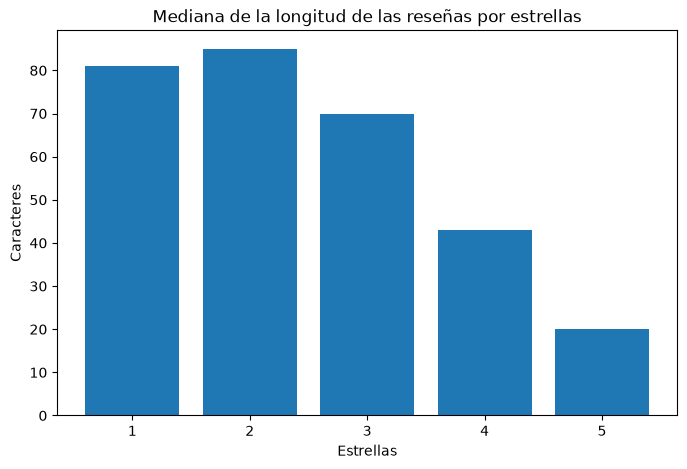

In [22]:
length_rating = pd.DataFrame({
    "Estrellas": ratings,
    "Longitud": analysis_text.str.len()
}).dropna()

length_summary_rating = (
    length_rating
    .groupby("Estrellas")["Longitud"]
    .agg(["count", "mean", "median"])
    .round(1)
)

display(length_summary_rating)

median_length = (
    length_rating
    .groupby("Estrellas")["Longitud"]
    .median()
)

plt.figure(figsize=(8, 5))

plt.bar(
    median_length.index,
    median_length.values
)

plt.title("Mediana de la longitud de las reseñas por estrellas")
plt.xlabel("Estrellas")
plt.ylabel("Caracteres")
plt.xticks([1, 2, 3, 4, 5])

plt.show()

## Hallazgos del EDA

### ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

Sí. Existen valores faltantes importantes en varias variables:

- title: **74,878 valores faltantes**, equivalentes al **93.51 %**.
- language: **68,382 valores faltantes**, equivalentes al **85.39 %**.
- rating: **7,881 valores faltantes**, equivalentes al **9.84 %**.

Se identifica un patrón claro en la ausencia de la variable **rating** las **7,881** reseñas sin estrellas corresponden a las plataformas X y YouTube, que no utilizan esquema de calificación que App Store y Google Play.

### ¿Cuáles son las estadísticas resumidas del conjunto de datos?

El conjunto de datos contiene:

- **80,079 registros**.
- **18 variables**.
- **4 plataformas**.

La distribución por plataforma es:

- Google Play: **66,997 reseñas**.
- X: **6,553 reseñas**.
- App Store: **5,201 reseñas**.
- YouTube: **1,328 reseñas**.

La distribución de estrellas es:

- 1 estrella: **12,774 reseñas**.
- 2 estrellas: **3,413 reseñas**.
- 3 estrellas: **4,684 reseñas**.
- 4 estrellas: **7,236 reseñas**.
- 5 estrellas: **44,091 reseñas**.

### ¿Hay valores atípicos en el conjunto de datos?

Sí. Se analizaron los valores atípicos utilizando la longitud de las reseñas y el método del rango intercuartílico (IQR).

Los resultados obtenidos fueron:

- Q1: **14 caracteres**.
- Q3: **92 caracteres**.
- IQR: **78 caracteres**.
- Límite superior: **209 caracteres**.
- Valores atípicos detectados: **6,096 reseñas**.
- Porcentaje de valores atípicos: **7.61 %**.

 Una reseña extensa puede contener información válida y relevante, especialmente cuando un usuario describe un problema con mayor detalle.

### ¿Cuál es la cardinalidad de las variables categóricas?

La cardinalidad varía considerablemente entre las variables.

Algunos ejemplos son:

- `platform`: **4 valores distintos**.
- `language`: **38 valores**.
- `date_basis`: **4 valores**.
- `date_precision`: **2 valores**.
- `date_timezone`: **2 valores**.
- `relevance`: **5 valores**.
- `preferred_provider`: **5 valores**.
- `identity_basis`: **3 valores**.
- `country`: **1 valores**.
- `app_id`: **2 valores**.



### ¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?

Sí. La longitud de las reseñas presenta una distribución sesgada hacia la derecha, debido a que la mayoría de los comentarios son relativamente cortos y existe un grupo menor de reseñas considerablemente más largas, sin embargo, esta transformación no debe aplicarse al contenido textual

### ¿Se identifican tendencias temporales?

Sí existe una dimensión temporal en el conjunto de datos y todas las reseñas cuentan con una fecha válida.

La cobertura temporal por plataforma es aproximadamente:

- App Store: de **2025-09-01 a 2026-09-18**.
- Google Play: de **2025-09-13 a 2026-09-26**.
- X: de **2025-09-01 a 2026-09-14**.
- YouTube: de **2025-09-01 a 2026-09-16**.

Se observan variaciones mensuales en el volumen de reseñas, aunque el análisis no muestra evidencia suficiente para afirmar que exista una tendencia sostenida o un patrón estacional.

Además, las fechas pueden representar distintos criterios según la plataforma, como fecha de publicación o actualización, por lo que la interpretación temporal debe realizarse con cautela.

### ¿Hay correlación entre las variables dependientes e independientes?

El análisis de correlación tradicional es limitado debido a que gran parte del conjunto de datos está compuesto por texto y variables categóricas, sin embargo, sí se observa una relación descriptiva entre la valoración y la longitud de las reseñas: las reseñas con bajas calificaciones tienden a ser más largas que las reseñas con calificaciones altas.
Esta relación representa una asociación, pero no implica causalidad.

### ¿Cómo se distribuyen los datos en función de diferentes categorías? — Análisis bivariado

El análisis bivariado muestra diferencias relevantes entre distintas categorías.

**Plataforma y estrellas:** App Store y Google Play presentan distribuciones distintas de calificaciones, mientras que X y YouTube no disponen de estrellas.

**Estrellas y longitud:** las reseñas con calificaciones bajas tienden a ser más extensas que las reseñas con calificaciones altas.

**Plataforma y duplicados:** se observan diferencias importantes en la proporción de textos duplicados entre plataformas.

**Estrellas y vocabulario:** existen diferencias claras en el uso de ciertas palabras entre reseñas con calificaciones bajas y altas.

Por ejemplo:

- La palabra **“no”** aparece en aproximadamente **58.64 %** de las reseñas de 1–2 estrellas y en **8.57 %** de las reseñas de 4–5 estrellas.
- La palabra **“excelente”** aparece en aproximadamente **23.06 %** de las reseñas de 4–5 estrellas y solo en **0.42 %** de las reseñas de 1–2 estrellas.

Estas diferencias muestran que existen patrones lingüísticos relacionados con la valoración otorgada.

### ¿Se deberían normalizar las imágenes para visualizarlas mejor?

**No aplica.**

El conjunto de datos utilizado está compuesto principalmente por texto y variables asociadas a las reseñas. 

### ¿Hay desequilibrio en las clases de la variable objetivo?

Sí. Existe un desequilibrio importante entre las clases.

Agrupando las estrellas de forma exploratoria:

- **Negativas (1–2 estrellas): 16,187 reseñas**.
- **Neutrales (3 estrellas): 4,684 reseñas**.
- **Positivas (4–5 estrellas): 51,327 reseñas**.

Entre las **72,198 reseñas con calificación**, esto representa aproximadamente:

- Negativas: **22.42 %**.
- Neutrales: **6.49 %**.
- Positivas: **71.09 %**.

La clase positiva domina claramente el conjunto de datos. Este desequilibrio deberá considerarse durante el modelado, especialmente al dividir los datos en entrenamiento y prueba.


### Conclusión general

El análisis exploratorio muestra que el conjunto de datos contiene información suficiente para continuar con una etapa de modelado de sentimiento, sin embargo, antes del entrenamiento deben considerarse especialmente tres aspectos:

- el **desequilibrio entre las clases**;
- la presencia de **textos duplicados**;
- y las **diferencias estructurales entre las plataformas**.

Estos elementos pueden influir de forma importante en el desempeño y en la interpretación de los modelos posteriores.


### Anexos

En la siguiente liga se encuentra una propuesta para el diseño técnico de producto.

https://docs.google.com/document/d/1fbupbxaR-6bSGGEHgjWfxgpiYtJda2jj/edit?usp=drive_link&ouid=100951346690511291514&rtpof=true&sd=true